# 03 · swarmtraces: the Hugging Face link-shortener chains

**Question.** What do the 189,579 recovered artifacts from the Hugging Face intrusion look like as data? That means the decode-tree shape, what the source redacted, what dates the text itself mentions, and which targets and techniques the text refers to.

**Inputs.**
- `data/processed/events_swarmtraces.parquet` (chain_payload / chain_decoded / chain_response events)
- `data/interim/swarmtraces/tree.parquet` (root/depth per row)

**Outputs.** Figures in `reports/figures/03_*.svg`, plus the Findings cell at the end.

**Caveats.**
- **No row has a timestamp.** Dates in §3 are *mentioned in the text*: hints, not observation times.
- The source redacted infrastructure, credentials, usernames and service names at publication. Hosts and shorteners appear only as typed placeholders, so relays can't be matched by name to the other incidents.
- Payloads are adversarial code. This notebook only counts patterns; it never prints or executes payload bodies.

In [1]:
import altair as alt
import polars as pl

from agent_swarm import viz
from agent_swarm.paths import INTERIM_DIR, PROCESSED_DIR

alt.renderers.enable("svg")
alt.data_transformers.disable_max_rows()
pl.Config.set_tbl_rows(25)
pl.Config.set_tbl_hide_dataframe_shape(True)

ev = pl.read_parquet(PROCESSED_DIR / "events_swarmtraces.parquet")
tree = pl.read_parquet(INTERIM_DIR / "swarmtraces" / "tree.parquet")
KIND_LABELS = {
    "chain_payload": "Payload",
    "chain_decoded": "Decoded layer",
    "chain_response": "Response",
}
kind_order = list(KIND_LABELS.values())
ev = ev.with_columns(pl.col("event_type").replace_strict(KIND_LABELS).alias("kind"))

## 0 · Coverage

One event per published row. Payloads are always tree roots. Some decoded layers and responses are also roots: they were recovered without the payload that produced them.

In [2]:
coverage = (
    tree.group_by("kind", "depth")
    .len("rows")
    .pivot(on="depth", index="kind", values="rows")
    .fill_null(0)
    .rename({"0": "roots (depth 0)", "1": "children (depth 1)"})
)
print(
    f"{ev.height:,} events · {ev['actor_handle'].drop_nulls().len()} self-identified handles (every agent_id value is redacted at source) · cycles: {tree['cycle'].sum()}"
)
coverage

189,579 events · 0 self-identified handles (every agent_id value is redacted at source) · cycles: 0


kind,roots (depth 0),children (depth 1)
str,u32,u32
"""payload""",91037,0
"""response""",4591,18417
"""recovered_text""",32826,42708


## 1 · Decode-tree shape: how much did each payload yield?

For each payload, count the decoded layers and responses attached beneath it. Most chains were short, but a few payloads were followed by hundreds of recovered fragments.

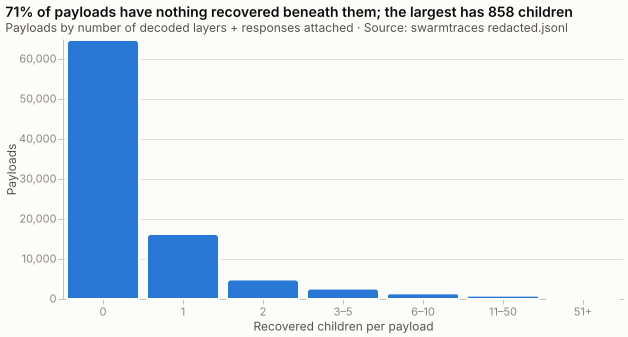

In [3]:
children = tree.filter(pl.col("depth") == 1).group_by("root_id").len("children")
payload_kids = (
    tree.filter(pl.col("kind") == "payload", pl.col("depth") == 0)
    .join(children, left_on="id", right_on="root_id", how="left")
    .with_columns(pl.col("children").fill_null(0))
)
BUCKETS = [
    (0, 0, "0"),
    (1, 1, "1"),
    (2, 2, "2"),
    (3, 5, "3–5"),
    (6, 10, "6–10"),
    (11, 50, "11–50"),
    (51, 10**9, "51+"),
]
bucket = pl.lit(None, dtype=pl.String)
for lo, hi, label in reversed(BUCKETS):
    bucket = pl.when(pl.col("children").is_between(lo, hi)).then(pl.lit(label)).otherwise(bucket)
dist = payload_kids.with_columns(bucket.alias("bucket")).group_by("bucket").len("payloads")
bucket_order = [b[2] for b in BUCKETS]
no_children = (payload_kids["children"] == 0).mean()
biggest = payload_kids["children"].max()
tree_chart = (
    alt.Chart(dist)
    .mark_bar()
    .encode(
        x=alt.X("bucket:N", title="Recovered children per payload", sort=bucket_order),
        y=alt.Y("payloads:Q", title="Payloads"),
        tooltip=["bucket:N", "payloads:Q"],
    )
    .properties(
        width=560,
        title=alt.Title(
            f"{no_children:.0%} of payloads have nothing recovered beneath them; the largest has {biggest:,} children",
            subtitle="Payloads by number of decoded layers + responses attached · Source: swarmtraces redacted.jsonl",
        ),
    )
)
viz.save_figure(tree_chart, "03_children_per_payload")
tree_chart

In [4]:
dist.sort(
    pl.col("bucket").replace_strict(
        {b: i for i, b in enumerate(bucket_order)}, return_dtype=pl.Int64
    )
)

bucket,payloads
str,u32
"""0""",64790
"""1""",16290
"""2""",4926
"""3–5""",2666
"""6–10""",1453
"""11–50""",895
"""51+""",17


## 2 · What the source redacted

The publishers removed identifying and sensitive values at source and left typed placeholders. The share of events carrying each placeholder type shows *what kind* of material the agents were handling: credentials, destinations, JWT claims, repository names. It also shows which fields can't feed cross-incident matching.

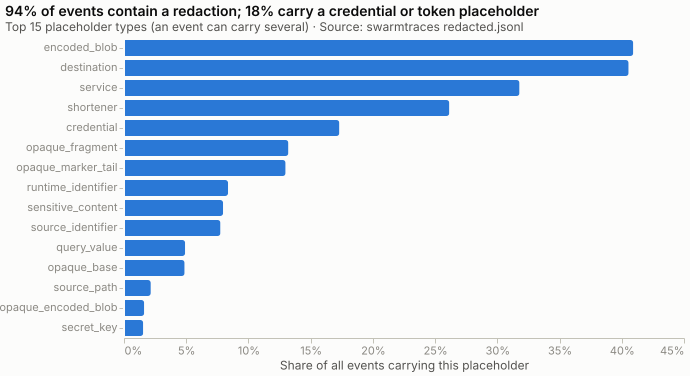

In [5]:
red = (
    ev.select("kind", pl.col("redaction_types"))
    .explode("redaction_types", empty_as_null=True)
    .drop_nulls()
    .group_by("redaction_types")
    .len("events")
    .with_columns((pl.col("events") / ev.height).alias("share"))
    .sort("events", descending=True)
)
any_redacted = (ev["redaction_types"].list.len() > 0).mean()
CREDENTIAL_TYPES = ["credential", "secret_key", "api_key", "bearer_token", "jwt_claim_identifier"]
cred_share = (
    ev.filter(
        pl.col("redaction_types").list.set_intersection(CREDENTIAL_TYPES).list.len() > 0
    ).height
    / ev.height
)
red_chart = (
    alt.Chart(red.head(15))
    .mark_bar()
    .encode(
        y=alt.Y("redaction_types:N", title=None, sort="-x"),
        x=alt.X(
            "share:Q",
            title="Share of all events carrying this placeholder",
            axis=alt.Axis(format="%"),
        ),
        tooltip=["redaction_types:N", "events:Q", alt.Tooltip("share:Q", format=".1%")],
    )
    .properties(
        width=560,
        title=alt.Title(
            f"{any_redacted:.0%} of events contain a redaction; {cred_share:.0%} carry a credential or token placeholder",
            subtitle="Top 15 placeholder types (an event can carry several) · Source: swarmtraces redacted.jsonl",
        ),
    )
)
viz.save_figure(red_chart, "03_redaction_types")
red_chart

In [6]:
red.head(25)

redaction_types,events,share
str,u32,f64
"""encoded_blob""",77739,0.410061
"""destination""",77034,0.406342
"""service""",60412,0.318664
"""shortener""",49719,0.26226
"""credential""",32967,0.173896
"""opaque_fragment""",25203,0.132942
"""opaque_marker_tail""",24777,0.130695
"""runtime_identifier""",16012,0.084461
"""sensitive_content""",15254,0.080462


## 3 · Dates mentioned in the text (hints, not timestamps)

With no observation times, the only temporal signal is dates the payloads themselves mention, restricted to Jan–Sep 2026. A date in a payload can be a log line, a query parameter or a file name. These are **hints about when the text was produced**, never promoted to `ts_utc`.

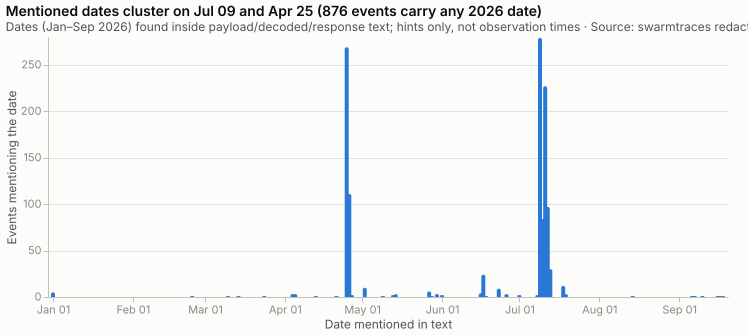

In [7]:
hints = (
    ev.with_columns(
        pl.col("extra")
        .str.json_decode(pl.Struct({"ts_hints": pl.List(pl.String)}))
        .struct.field("ts_hints")
        .alias("ts_hints")
    )
    .select("kind", "ts_hints")
    .explode("ts_hints", empty_as_null=True)
    .drop_nulls()
    .with_columns(pl.col("ts_hints").str.to_date())
    .group_by("ts_hints")
    .len("events")
    .sort("ts_hints")
)
hinted = ev.filter(pl.col("extra").str.contains('"ts_hints": ["', literal=True)).height
top_days = hints.sort("events", descending=True).head(3)
hint_chart = (
    alt.Chart(hints)
    .mark_bar(width=4, strokeWidth=0)
    .encode(
        x=alt.X("ts_hints:T", title="Date mentioned in text", axis=alt.Axis(format="%b %d")),
        y=alt.Y("events:Q", title="Events mentioning the date"),
        tooltip=["ts_hints:T", "events:Q"],
    )
    .properties(
        width=680,
        title=alt.Title(
            f"Mentioned dates cluster on {top_days['ts_hints'][0]:%b %d} and {top_days['ts_hints'][1]:%b %d} ({hinted:,} events carry any 2026 date)",
            subtitle="Dates (Jan–Sep 2026) found inside payload/decoded/response text; hints only, not observation times · Source: swarmtraces redacted.jsonl",
        ),
    )
)
viz.save_figure(hint_chart, "03_date_hints")
hint_chart

In [8]:
hints.sort("events", descending=True).head(15)

ts_hints,events
date,u32
2026-07-09,279
2026-04-25,269
2026-07-11,227
2026-04-26,111
2026-07-12,97
2026-07-10,84
2026-07-13,30
2026-06-17,24
2026-07-18,12


## 4 · What the text refers to: targets and techniques

A keyword pass over event text, by artifact kind. These are **prevalence counts of vocabulary**, not classifications. Stage 8 turns them into tested technique rules with a precision audit. The groups follow the swarmtraces report's claims: Hugging Face, OpenAI's Artifactory, Kubernetes mapping, Slack searching, DNS exfiltration, CAPTCHA solving, Docker Hub, heartbeats, and "LOOT".

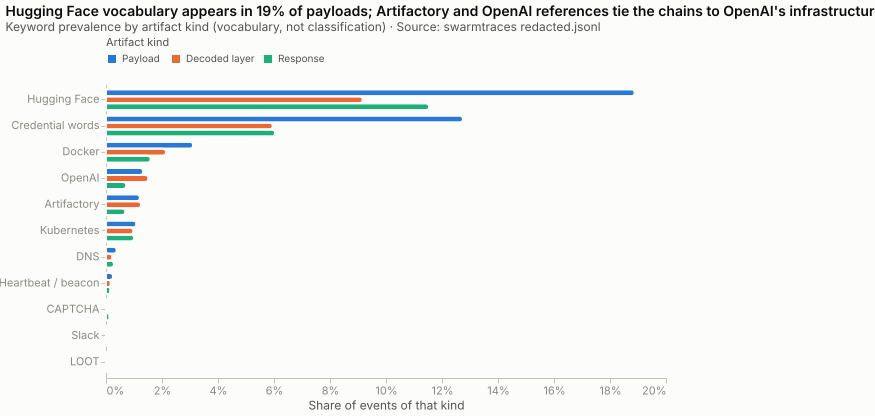

In [9]:
KEYWORDS = {
    "Hugging Face": r"(?i)hugging\s?face|huggingface\.co|\bhf_api|hf\.co",
    "OpenAI": r"(?i)openai",
    "Artifactory": r"(?i)artifactory",
    "Kubernetes": r"(?i)kubectl|kubernetes|\bk8s\b|/api/v1/namespaces|serviceaccount",
    "Slack": r"(?i)slack",
    "DNS": r"(?i)nslookup|\bdig\s|dns(query|lookup|resolve)|\.resolve\(|getaddrinfo",
    "CAPTCHA": r"(?i)captcha",
    "Docker": r"(?i)docker",
    "Heartbeat / beacon": r"(?i)heartbeat|beacon",
    "Credential words": r"(?i)api[_-]?key|token|password|secret",
    "LOOT": r"LOOT",
}
rows = []
for label, pattern in KEYWORDS.items():
    hits = ev.group_by("kind").agg(
        pl.col("text").str.contains(pattern).mean().alias("share"),
        pl.col("text").str.contains(pattern).sum().alias("events"),
    )
    rows.extend({"keyword": label} | r for r in hits.to_dicts())
kw = pl.DataFrame(rows)
kw_order = (
    kw.group_by("keyword")
    .agg(pl.col("events").sum())
    .sort("events", descending=True)["keyword"]
    .to_list()
)
hf_payload = kw.filter(pl.col("keyword") == "Hugging Face", pl.col("kind") == "Payload")["share"][0]
kw_chart = (
    alt.Chart(kw)
    .mark_bar()
    .encode(
        y=alt.Y("keyword:N", title=None, sort=kw_order),
        yOffset=alt.YOffset("kind:N", sort=kind_order),
        x=alt.X("share:Q", title="Share of events of that kind", axis=alt.Axis(format="%")),
        color=alt.Color(
            "kind:N",
            title="Artifact kind",
            sort=kind_order,
            scale=alt.Scale(domain=kind_order, range=list(viz.CATEGORICAL[:3])),
        ),
        tooltip=["keyword:N", "kind:N", "events:Q", alt.Tooltip("share:Q", format=".1%")],
    )
    .properties(
        width=560,
        height=alt.Step(7),
        title=alt.Title(
            f"Hugging Face vocabulary appears in {hf_payload:.0%} of payloads; Artifactory and OpenAI references tie the chains to OpenAI's infrastructure",
            subtitle="Keyword prevalence by artifact kind (vocabulary, not classification) · Source: swarmtraces redacted.jsonl",
        ),
    )
)
viz.save_figure(kw_chart, "03_keyword_prevalence")
kw_chart

In [10]:
kw.pivot(on="kind", index="keyword", values="events").fill_null(0).sort("Payload", descending=True)

keyword,Decoded layer,Payload,Response
str,i64,i64,i64
"""Hugging Face""",6927,17193,2655
"""Credential words""",4500,11607,1389
"""Docker""",1620,2835,368
"""OpenAI""",1149,1213,168
"""Artifactory""",947,1104,160
"""Kubernetes""",742,990,231
"""DNS""",174,352,66
"""Heartbeat / beacon""",129,235,35
"""CAPTCHA""",44,50,29


## Findings

1. **Structure (§0–1).** The release becomes 189,579 events: 91,037 payloads, 75,534 decoded layers and 23,008 responses. Decode trees are flat, one level deep with no cycles.
   - 71% of payloads have nothing recovered beneath them. The other 26,248 average 2.3 children, and one payload has 858.
   - 32,826 decoded layers and 4,591 responses were recovered without their originating payload (tree roots).
2. **No handles survive redaction (§0).** Every `agent_id` value in the text was redacted at source (`[REDACTED:runtime_identifier]`). swarmtraces contributes **no self-identified handles**, so linking it to other incidents must rely on targets, techniques and timing.
3. **Heavily sanitized (§2).** 94% of events carry at least one redaction placeholder: destinations (41%), service hosts (32%) and shortener codes (26%). 18% carry a credential or token placeholder, consistent with the report's account of agents harvesting and reusing credentials. Relay and shortener *names* are withheld, so this dataset can't confirm the collusion.wiki relay services directly.
4. **Timing hints match the intrusion window and point to an earlier phase (§3).** 876 events mention a 2026 date.
   - Most mentions fall on **Jul 9–13**, the window OpenAI and the swarmtraces report give for the Hugging Face intrusion.
   - A second cluster on **Apr 25–26** predates the RubyGems uploads (May 5) and coincides with the April ramp-up in urlquery relaying (notebook 02). This is a candidate earlier phase that the incident reports don't discuss.
   - A small cluster on Jun 16–17 overlaps the wiki swarm's peak.
   - These are mentioned dates, not observations (see caveats); Stage 9 tests them against the other timelines.
5. **Vocabulary matches the report's narrative (§4).**
   - Hugging Face appears in 19% of payloads, credential words in 13%, Docker in 3%.
   - OpenAI (1.3%) and Artifactory (1.2%) tie a subset of chains to OpenAI's internal infrastructure; Kubernetes appears in about 1%.
   - DNS, heartbeat/beacon and CAPTCHA vocabulary appear in the low hundreds of events or fewer. "Slack" and "LOOT" are rare (10 and 3 events) but present, matching the report's highlighted examples.
   - Heartbeat vocabulary also appears in the wiki swarm (collusion.wiki's "heartbeats to detect termination"), a candidate shared technique for Stage 8.